# Análisis exploratorio de datos (EDA)

**Problema:** predicción temprana de deserción en educación superior. Cada fila representa a un estudiante y `Target` contiene el resultado final (`Dropout`, `Enrolled` o `Graduate`).

Este análisis responde a los objetivos del proyecto: revisar la estructura y calidad del dataset, caracterizar el desbalance de clases, explorar asociaciones con el contexto y el desempeño académico, y documentar el riesgo de *data leakage*. El escenario de alerta temprana se limita a variables disponibles al matricularse y al cierre del primer semestre; las del segundo semestre se inspeccionan solo para entender su relación con el resultado, no como predictores del escenario principal.

El CSV contiene 36 predictores más `Target` (37 columnas). UCI registra 36 *features* y el objetivo por separado; el README menciona que el artículo reporta 35 atributos, diferencia que conviene contrastar con la publicación. Para la definición, codificación y disponibilidad de cada variable, consultar el [diccionario del proyecto](../reports/diccionario_variables.md).

Las asociaciones descritas son exploratorias y no implican causalidad. Los códigos enteros de variables categóricas se interpretan con el codebook UCI, no como magnitudes.

In [29]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams["figure.figsize"] = (10, 5)

DATA_PATH = Path("../data/raw/data.csv")
df = pd.read_csv(DATA_PATH, sep=";")
df.columns = df.columns.str.strip()

dataset_overview = pd.DataFrame({
    "Métrica": ["Estudiantes", "Columnas totales", "Predictores", "Clases objetivo", "Memoria en uso (MiB)"],
    "Valor": [
        len(df),
        df.shape[1],
        df.shape[1] - 1,
        df["Target"].nunique(),
        round(df.memory_usage(deep=True).sum() / 1024**2, 2),
    ],
})
display(dataset_overview)

,Métrica,Valor
0,Estudiantes,4424.00
1,Columnas totales,37.00
2,Predictores,36.00
3,Clases objetivo,3.00
4,Memoria en uso (MiB),1.45


## 1. Estructura y calidad

La UCI declara 36 predictores; junto con `Target`, el archivo esperado tiene 37 columnas y 4.424 estudiantes. El resumen de calidad y la tabla de tipos comparan lo observado con esa ficha.

El tipo inferido por pandas no basta para decidir cómo analizar o transformar una variable: códigos como `Course`, `Application mode` y ocupaciones son nominales; `Application order` sí representa un orden; los indicadores 0/1 son binarios. Las categorías codificadas como “desconocido” o “vacío” tampoco son necesariamente valores nulos. Consultar el [diccionario de variables](../reports/diccionario_variables.md) para sus definiciones.

In [30]:
nominal_cols = [
    "Marital status", "Application mode", "Course", "Previous qualification",
    "Nacionality", "Mother's qualification", "Father's qualification",
    "Mother's occupation", "Father's occupation",
]
binary_cols = [
    "Daytime/evening attendance", "Displaced", "Educational special needs",
    "Debtor", "Tuition fees up to date", "Gender", "Scholarship holder", "International",
]
ordinal_cols = ["Application order"]
semantic_types = {
    **{col: "Categórica nominal" for col in nominal_cols},
    **{col: "Categórica binaria" for col in binary_cols},
    **{col: "Categórica ordinal" for col in ordinal_cols},
}
for col in df.columns:
    semantic_types.setdefault(col, "Cuantitativa" if col != "Target" else "Objetivo categórico")

semantic_type_summary = pd.DataFrame({
    "tipo_semantico": pd.Series(semantic_types),
    "dtype_csv": df.dtypes,
    "valores_distintos": df.nunique(dropna=False),
})
display(semantic_type_summary.sort_values(["tipo_semantico", "valores_distintos"]))

quality_summary = pd.DataFrame({
    "Métrica": ["Filas esperadas (README)", "Columnas esperadas (README)", "Valores faltantes", "Filas duplicadas exactas", "Columnas constantes"],
    "Valor": [
        len(df) == 4424,
        df.shape[1] == 37,
        int(df.isna().sum().sum()),
        int(df.duplicated().sum()),
        int(sum(df[col].nunique(dropna=False) <= 1 for col in df.columns)),
    ],
})
display(quality_summary)

binary_check = {
    col: sorted(df[col].dropna().unique().tolist())
    for col in binary_cols
    if col in df.columns
}
display(pd.Series(binary_check, name="Códigos observados").to_frame())

,tipo_semantico,dtype_csv,valores_distintos
Daytime/evening attendance,Categórica binaria,int64,2
Debtor,Categórica binaria,int64,2
Displaced,Categórica binaria,int64,2
Educational special needs,Categórica binaria,int64,2
Gender,Categórica binaria,int64,2
International,Categórica binaria,int64,2
Scholarship holder,Categórica binaria,int64,2
Tuition fees up to date,Categórica binaria,int64,2
Marital status,Categórica nominal,int64,6
Course,Categórica nominal,int64,17


,Métrica,Valor
0,Filas esperadas (README),True
1,Columnas esperadas (README),True
2,Valores faltantes,0
3,Filas duplicadas exactas,0
4,Columnas constantes,0


,Códigos observados
Daytime/evening attendance,"[0, 1]"
Displaced,"[0, 1]"
Educational special needs,"[0, 1]"
Debtor,"[0, 1]"
Tuition fees up to date,"[0, 1]"
Gender,"[0, 1]"
Scholarship holder,"[0, 1]"
International,"[0, 1]"


## 2. Variable objetivo y desbalance

La tabla y el gráfico resumen `Dropout`, `Enrolled` y `Graduate`. `Enrolled` significa que el estudiante seguía matriculado al cierre del período observado; no confirma por sí solo su resultado posterior.

En este dataset `Graduate` es la clase mayoritaria (49,9%). Un clasificador trivial que siempre elija esa clase obtiene 49,9% de accuracy, pero 0% de recall para `Dropout`; por eso accuracy no basta. El README prioriza recall de `Dropout` y F1 macro, y solicita comparar el modelo con este baseline.

,Estudiantes,Porcentaje
Target,,
Graduate,2209,49.93
Dropout,1421,32.12
Enrolled,794,17.95


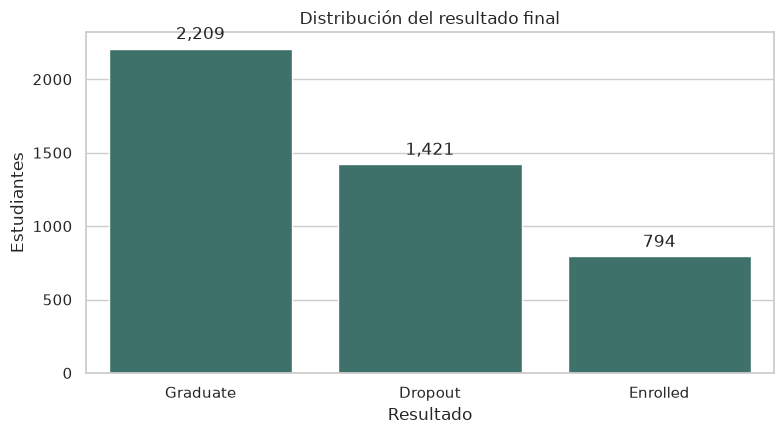

,Referencia,Valor
0,Clase mayoritaria,Graduate
1,Accuracy del baseline,49.9%
2,Recall de Dropout del baseline,0.0%


In [31]:
class_summary = (
    df["Target"].value_counts()
    .rename_axis("Target")
    .to_frame("Estudiantes")
)
class_summary["Porcentaje"] = 100 * class_summary["Estudiantes"] / len(df)
display(class_summary.round(2))

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.countplot(data=df, x="Target", order=class_summary.index, color="#347a70", ax=ax)
ax.set(title="Distribución del resultado final", xlabel="Resultado", ylabel="Estudiantes")
for bar in ax.patches:
    ax.annotate(
        f"{int(bar.get_height()):,}",
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        ha="center", va="bottom", xytext=(0, 4), textcoords="offset points",
    )
plt.tight_layout()
plt.show()

majority_class = class_summary["Estudiantes"].idxmax()
majority_share = class_summary.loc[majority_class, "Porcentaje"]
dropout_share = class_summary.loc["Dropout", "Porcentaje"]
baseline_summary = pd.DataFrame({
    "Referencia": ["Clase mayoritaria", "Accuracy del baseline", "Recall de Dropout del baseline"],
    "Valor": [majority_class, f"{majority_share:.1f}%", "0.0%"],
})
display(baseline_summary)

## 3. Variables cuantitativas y desempeño inicial

Las calificaciones de admisión y previas están en escala 0–200; la nota promedio semestral, en escala 0–20. Los conteos representan unidades curriculares. Para hacer comparable el progreso entre estudiantes, se calcula además `unidades aprobadas / unidades matriculadas` al cierre del primer semestre. Si no hay unidades matriculadas, esa tasa queda indefinida (`NaN`), no se fuerza a cero.

,count,mean,std,min,25%,50%,75%,max
Age at enrollment,4424.0,23.27,7.59,17.00,19.0,20.00,25.00,70.00
Previous qualification (grade),4424.0,132.61,13.19,95.00,125.0,133.10,140.00,190.00
Admission grade,4424.0,126.98,14.48,95.00,117.9,126.10,134.80,190.00
Curricular units 1st sem (enrolled),4424.0,6.27,2.48,0.00,5.0,6.00,7.00,26.00
Curricular units 1st sem (evaluations),4424.0,8.30,4.18,0.00,6.0,8.00,10.00,45.00
Curricular units 1st sem (approved),4424.0,4.71,3.09,0.00,3.0,5.00,6.00,26.00
Curricular units 1st sem (grade),4424.0,10.64,4.84,0.00,11.0,12.29,13.40,18.88
Unemployment rate,4424.0,11.57,2.66,7.60,9.4,11.10,13.90,16.20
Inflation rate,4424.0,1.23,1.38,-0.80,0.3,1.40,2.60,3.70
GDP,4424.0,0.00,2.27,-4.06,-1.7,0.32,1.79,3.51


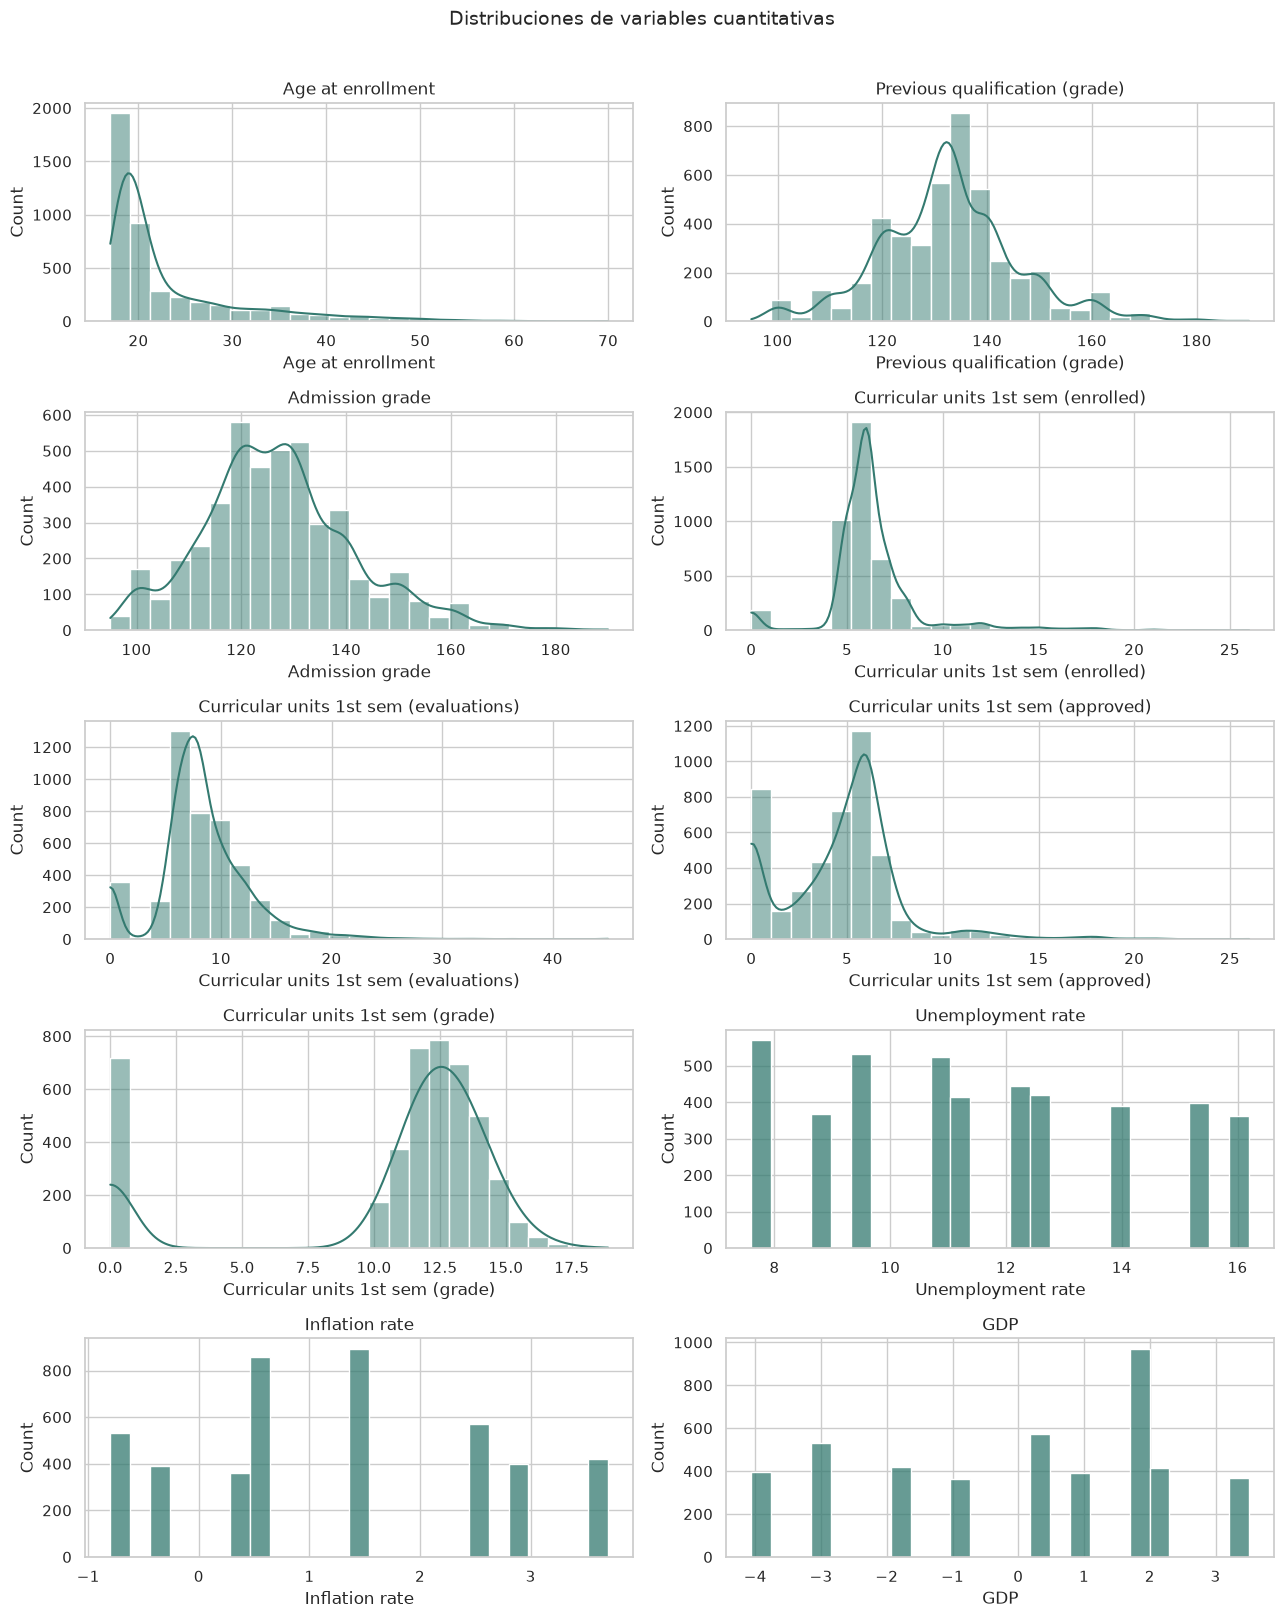

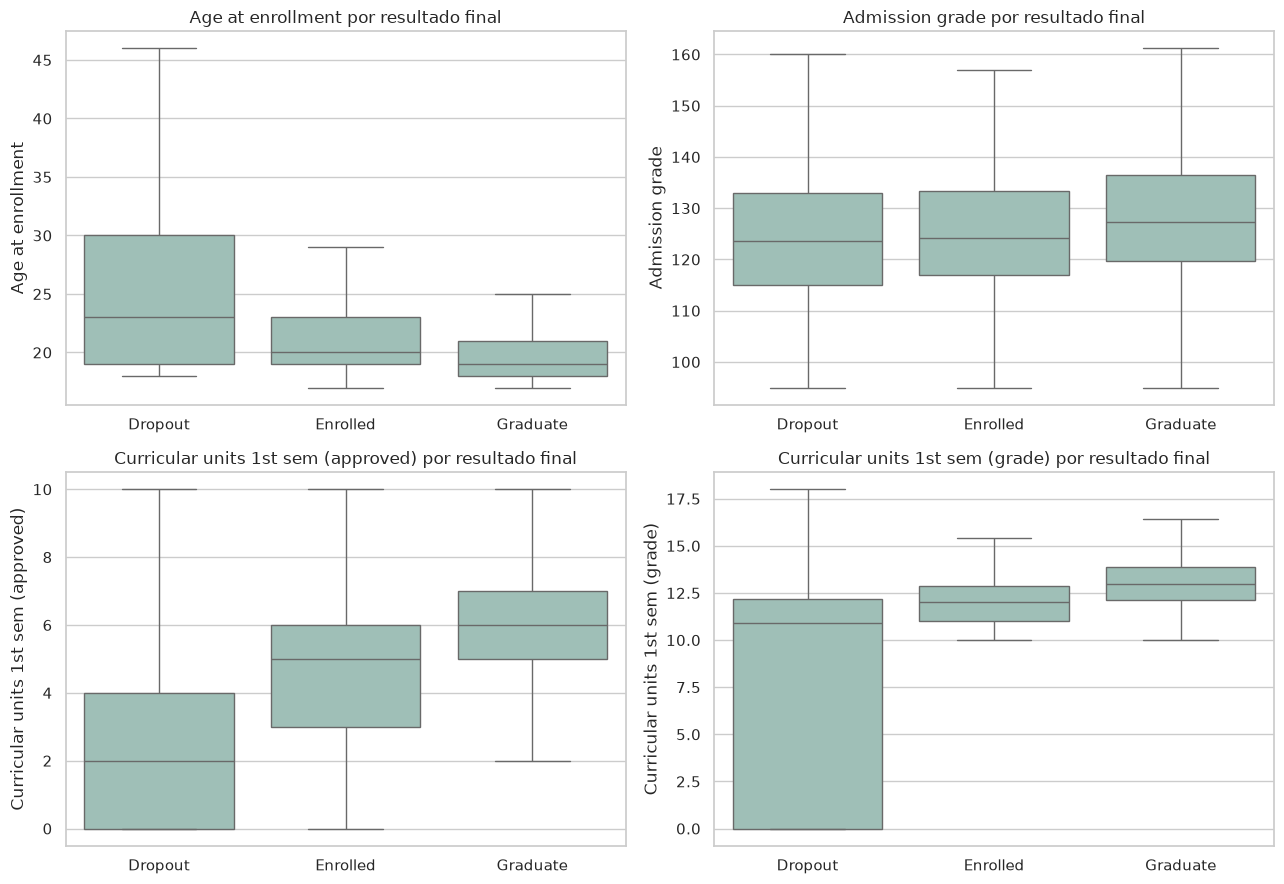

,estudiantes,mediana_matriculadas,mediana_aprobadas,mediana_tasa_aprobacion_pct,sin_matricula_pct,sin_aprobadas_pct
Target,,,,,,
Dropout,1421,6.0,2.0,40.0,5.4,40.1
Enrolled,794,6.0,5.0,80.0,3.5,8.9
Graduate,2209,6.0,6.0,100.0,3.4,3.5


,Control,Estudiantes
0,Sin unidades matriculadas (tasa indefinida),180
1,Aprobadas superiores a matriculadas,0


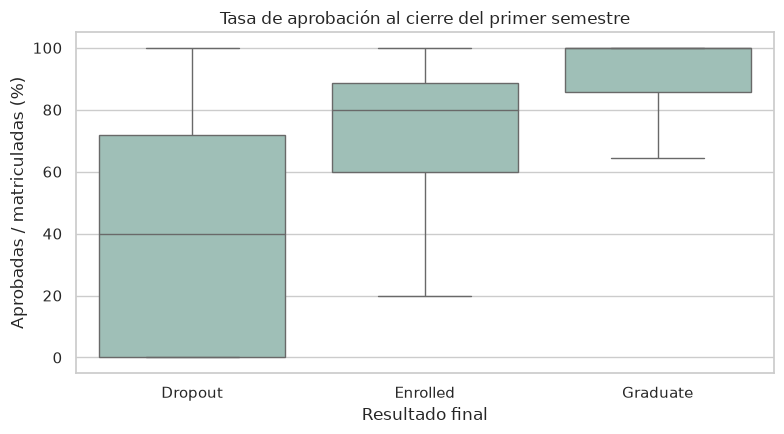

In [32]:
quantitative_cols = [
    "Age at enrollment", "Previous qualification (grade)", "Admission grade",
    "Curricular units 1st sem (enrolled)",
    "Curricular units 1st sem (evaluations)",
    "Curricular units 1st sem (approved)", "Curricular units 1st sem (grade)",
    "Unemployment rate", "Inflation rate", "GDP",
]
quantitative_cols = [col for col in quantitative_cols if col in df.columns]
display(df[quantitative_cols].describe().T.round(2))

ncols = 2
nrows = int(np.ceil(len(quantitative_cols) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(13, 3.2 * nrows))
for ax, col in zip(np.asarray(axes).reshape(-1), quantitative_cols):
    sns.histplot(data=df, x=col, bins=25, kde=(df[col].nunique() > 10), ax=ax, color="#347a70")
    ax.set_title(col)
for ax in np.asarray(axes).reshape(-1)[len(quantitative_cols):]:
    ax.set_visible(False)
fig.suptitle("Distribuciones de variables cuantitativas", y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

first_semester_cols = [
    "Age at enrollment", "Admission grade",
    "Curricular units 1st sem (approved)", "Curricular units 1st sem (grade)",
]
first_semester_cols = [col for col in first_semester_cols if col in df.columns]
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, col in zip(axes.flat, first_semester_cols):
    sns.boxplot(data=df, x="Target", y=col, order=["Dropout", "Enrolled", "Graduate"], ax=ax, color="#9ac4b9", showfliers=False)
    ax.set_title(f"{col} por resultado final")
    ax.set_xlabel("")
plt.tight_layout()
plt.show()

# La tasa se mantiene fuera de df para preservar intactas las columnas y calidad del CSV original.
enrolled_col = "Curricular units 1st sem (enrolled)"
approved_col = "Curricular units 1st sem (approved)"
first_sem_approval_rate_pct = (
    100 * df[approved_col] / df[enrolled_col].where(df[enrolled_col] > 0)
)
first_sem_rate_data = df.assign(first_sem_approval_rate_pct=first_sem_approval_rate_pct)
zero_enrollment_count = int(df[enrolled_col].eq(0).sum())
approval_exceeds_enrollment = int((df[approved_col] > df[enrolled_col]).sum())
first_sem_summary = first_sem_rate_data.groupby("Target").agg(
    estudiantes=("Target", "size"),
    mediana_matriculadas=(enrolled_col, "median"),
    mediana_aprobadas=(approved_col, "median"),
    mediana_tasa_aprobacion_pct=("first_sem_approval_rate_pct", "median"),
    sin_matricula_pct=(enrolled_col, lambda values: 100 * values.eq(0).mean()),
    sin_aprobadas_pct=(approved_col, lambda values: 100 * values.eq(0).mean()),
).reindex(["Dropout", "Enrolled", "Graduate"])
display(first_sem_summary.round(1))

diagnostics_summary = pd.DataFrame({
    "Control": ["Sin unidades matriculadas (tasa indefinida)", "Aprobadas superiores a matriculadas"],
    "Estudiantes": [zero_enrollment_count, approval_exceeds_enrollment],
})
display(diagnostics_summary)

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.boxplot(
    data=first_sem_rate_data, x="Target", y="first_sem_approval_rate_pct",
    order=["Dropout", "Enrolled", "Graduate"], showfliers=False,
    color="#9ac4b9", ax=ax,
)
ax.set(title="Tasa de aprobación al cierre del primer semestre", xlabel="Resultado final", ylabel="Aprobadas / matriculadas (%)")
plt.tight_layout()
plt.show()

## 4. Contexto y segmentos

Las tasas se calculan dentro de cada grupo y se acompañan de su tamaño `n`. En los datos observados, `Dropout` es 25,1% entre mujeres (`n=2.868`) y 45,1% entre hombres (`n=1.556`); es 12,2% entre estudiantes con beca (`n=1.099`) y 38,7% entre quienes no la tienen (`n=3.325`). Para quienes no tienen los pagos al día, la tasa es 86,6% (`n=528`). Son diferencias descriptivas, no efectos causales, y algunas variables requieren revisión de equidad antes de usarse en decisiones de acompañamiento.

El diccionario permite mostrar carrera por nombre y no por código. Entre las carreras con al menos 30 estudiantes, Equinculture presenta la tasa observada más alta (55,3%; `n=141`). `Application order` es ordinal: 0 indica primera opción y 9 última. Las categorías con menos de 30 casos quedan en la tabla, pero se omiten del gráfico para no sobrerrepresentar tasas inestables.

,variable,categoria_codificada,categoria,estudiantes,dropout_pct,enrolled_pct,graduate_pct
0,Gender,0,Femenino,2868,25.1,17.0,57.9
1,Gender,1,Masculino,1556,45.1,19.7,35.2
2,Scholarship holder,0,No beca,3325,38.7,20.0,41.3
3,Scholarship holder,1,Con beca,1099,12.2,11.8,76.0
4,Tuition fees up to date,0,No al día,528,86.6,8.0,5.5
5,Tuition fees up to date,1,Al día,3896,24.7,19.3,56.0
6,Debtor,0,No deudor,3921,28.3,18.0,53.8
7,Debtor,1,Deudor,503,62.0,17.9,20.1
8,Displaced,0,No desplazado,1998,37.6,18.1,44.3
9,Displaced,1,Desplazado,2426,27.6,17.8,54.6


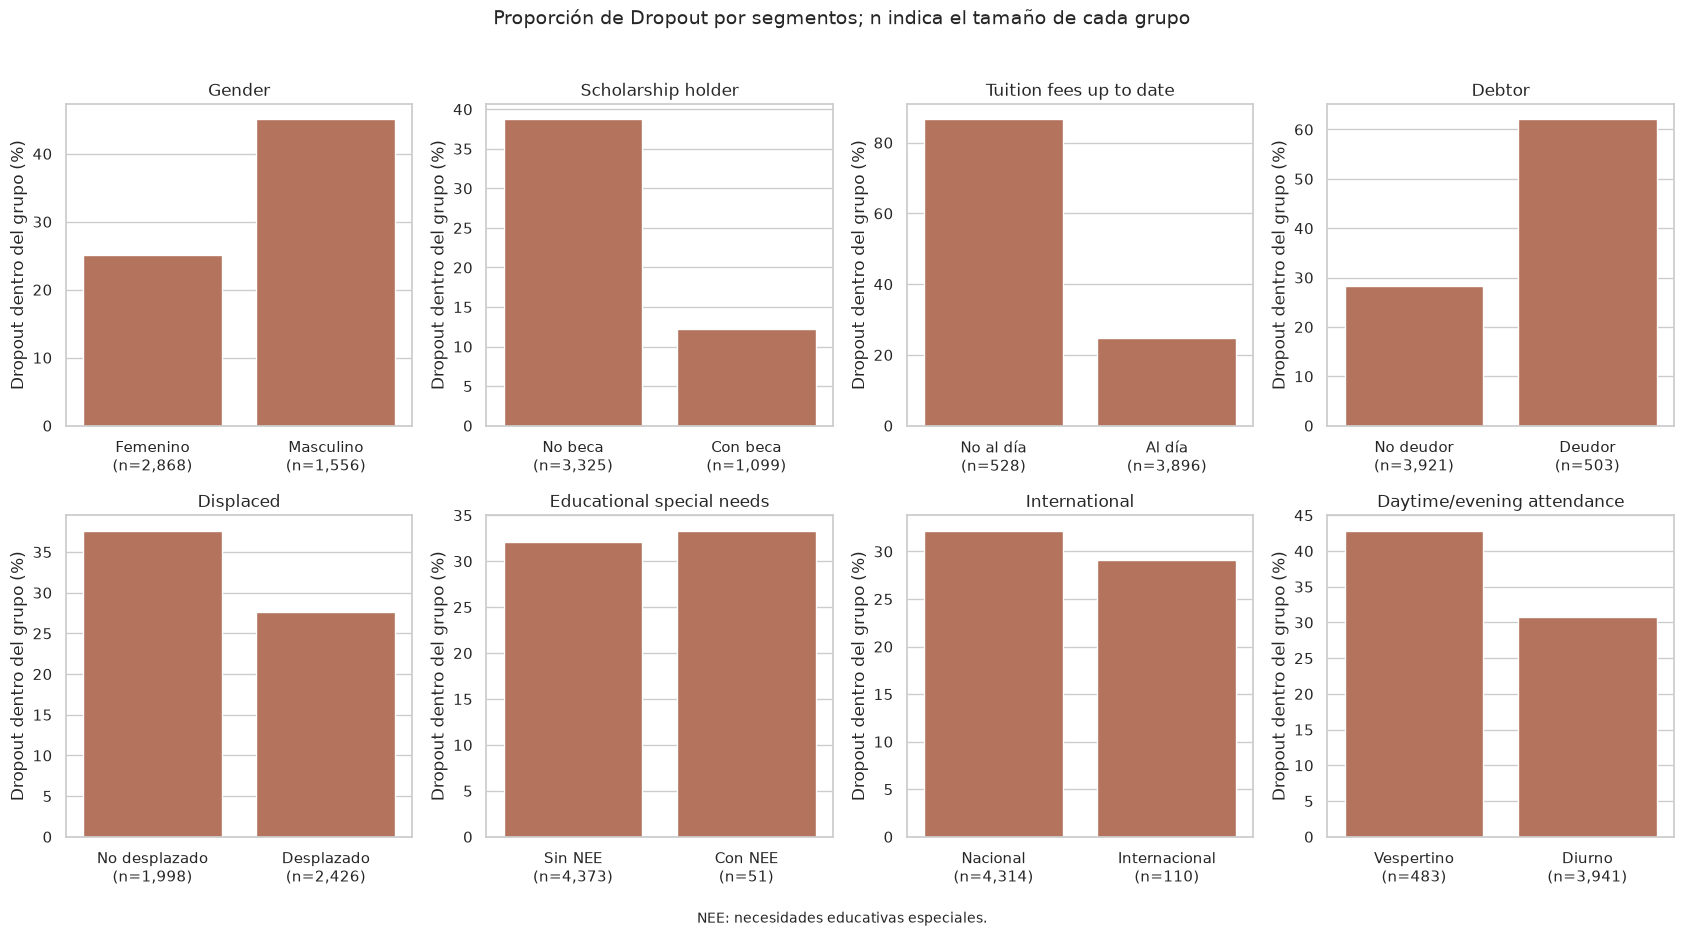

,carrera,estudiantes,dropout_pct,enrolled_pct,graduate_pct
Course,,,,,
9147,Management,380,35.3,28.4,36.3
9670,Advertising and Marketing Management,268,35.4,17.9,46.6
9254,Tourism,252,38.1,16.3,45.6
171,Animation and Multimedia Design,215,38.1,17.2,44.7
9556,Oral Hygiene,86,38.4,19.8,41.9
9003,Agronomy,210,41.0,17.6,41.4
9853,Basic Education,192,44.3,26.0,29.7
9991,Management (evening attendance),268,50.7,20.1,29.1
9119,Informatics Engineering,170,54.1,37.6,8.2


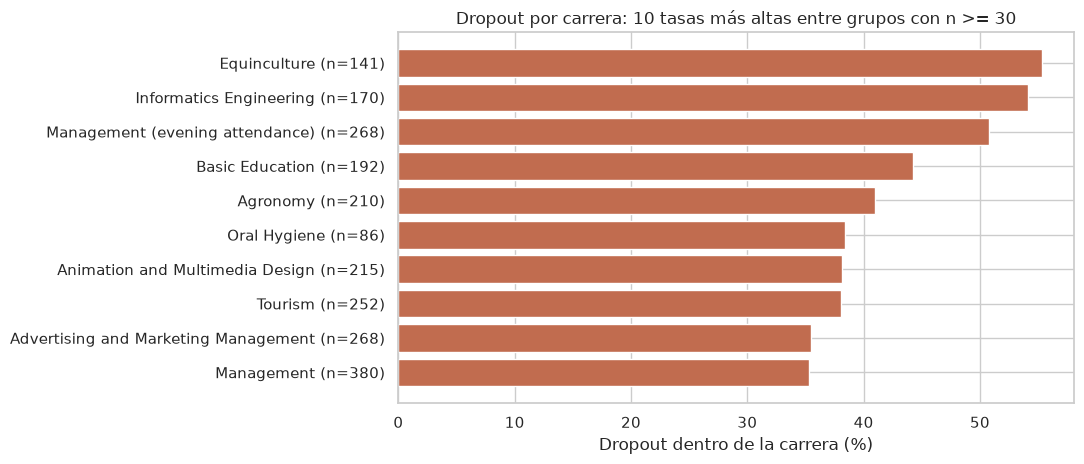

,estudiantes,dropout_pct,graduate_pct
Application order,,,
0,1,0.0,100.0
1,3026,34.8,46.5
2,547,27.4,55.0
3,309,24.6,56.0
4,249,23.3,64.3
5,154,34.4,49.4
6,137,22.6,65.7
9,1,0.0,0.0


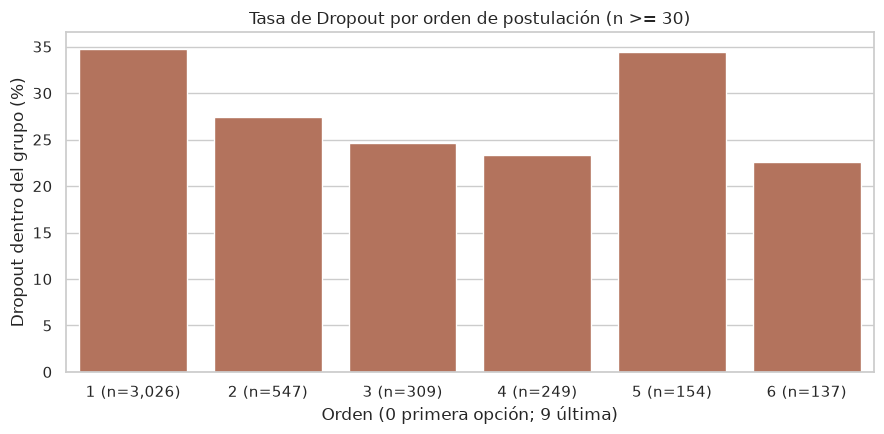

In [33]:
segment_label_maps = {
    "Gender": {0: "Femenino", 1: "Masculino"},
    "Scholarship holder": {0: "No beca", 1: "Con beca"},
    "Tuition fees up to date": {0: "No al día", 1: "Al día"},
    "Debtor": {0: "No deudor", 1: "Deudor"},
    "Displaced": {0: "No desplazado", 1: "Desplazado"},
    "Educational special needs": {0: "Sin NEE", 1: "Con NEE"},
    "International": {0: "Nacional", 1: "Internacional"},
    "Daytime/evening attendance": {0: "Vespertino", 1: "Diurno"},
}
segment_cols = list(segment_label_maps)
segment_cols = [col for col in segment_cols if col in df.columns]
segment_summaries = []

for col in segment_cols:
    counts = df.groupby(col, observed=True)["Target"].value_counts().unstack(fill_value=0)
    for target in ["Dropout", "Enrolled", "Graduate"]:
        if target not in counts.columns:
            counts[target] = 0
    group_sizes = counts.sum(axis=1)
    labels = [segment_label_maps[col].get(value, str(value)) for value in counts.index]
    summary = pd.DataFrame({
        "variable": col,
        "categoria_codificada": counts.index.astype(str),
        "categoria": labels,
        "estudiantes": group_sizes.values,
        "dropout_pct": (100 * counts["Dropout"] / group_sizes).values,
        "enrolled_pct": (100 * counts["Enrolled"] / group_sizes).values,
        "graduate_pct": (100 * counts["Graduate"] / group_sizes).values,
    })
    segment_summaries.append(summary)

segment_summary = pd.concat(segment_summaries, ignore_index=True)
display(segment_summary.round(1))

fig, axes = plt.subplots(2, 4, figsize=(17, 9))
for ax, col in zip(axes.flat, segment_cols):
    plot_data = segment_summary[segment_summary["variable"] == col].copy()
    plot_data["etiqueta"] = [
        f"{label}\n(n={size:,})"
        for label, size in zip(plot_data["categoria"], plot_data["estudiantes"])
    ]
    sns.barplot(data=plot_data, x="etiqueta", y="dropout_pct", ax=ax, color="#c16c4f")
    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("Dropout dentro del grupo (%)")
    ax.tick_params(axis="x", labelrotation=0)
for ax in axes.flat[len(segment_cols):]:
    ax.set_visible(False)
fig.suptitle("Proporción de Dropout por segmentos; n indica el tamaño de cada grupo", y=1.02, fontsize=14)
fig.text(0.5, 0.005, "NEE: necesidades educativas especiales.", ha="center", fontsize=10)
plt.tight_layout(rect=(0, 0.025, 1, 1))
plt.show()

course_names = {
    33: "Biofuel Production Technologies",
    171: "Animation and Multimedia Design",
    8014: "Social Service (evening attendance)",
    9003: "Agronomy",
    9070: "Communication Design",
    9085: "Veterinary Nursing",
    9119: "Informatics Engineering",
    9130: "Equinculture",
    9147: "Management",
    9238: "Social Service",
    9254: "Tourism",
    9500: "Nursing",
    9556: "Oral Hygiene",
    9670: "Advertising and Marketing Management",
    9773: "Journalism and Communication",
    9853: "Basic Education",
    9991: "Management (evening attendance)",
}
course_summary = df.groupby("Course").agg(
    estudiantes=("Target", "size"),
    dropout_pct=("Target", lambda values: 100 * values.eq("Dropout").mean()),
    enrolled_pct=("Target", lambda values: 100 * values.eq("Enrolled").mean()),
    graduate_pct=("Target", lambda values: 100 * values.eq("Graduate").mean()),
)
course_summary["carrera"] = [course_names.get(code, f"Código {code}") for code in course_summary.index]
minimum_course_n = 30
supported_courses = course_summary[course_summary["estudiantes"] >= minimum_course_n]
top_courses = supported_courses.nlargest(10, "dropout_pct").sort_values("dropout_pct")
display(top_courses[["carrera", "estudiantes", "dropout_pct", "enrolled_pct", "graduate_pct"]].round(1))

fig, ax = plt.subplots(figsize=(11, max(4.5, 0.48 * len(top_courses))))
course_labels = [f"{name} (n={size:,})" for name, size in zip(top_courses["carrera"], top_courses["estudiantes"])]
ax.barh(course_labels, top_courses["dropout_pct"], color="#c16c4f")
ax.set(title="Dropout por carrera: 10 tasas más altas entre grupos con n >= 30", xlabel="Dropout dentro de la carrera (%)", ylabel="")
plt.tight_layout()
plt.show()

order_summary = df.groupby("Application order").agg(
    estudiantes=("Target", "size"),
    dropout_pct=("Target", lambda values: 100 * values.eq("Dropout").mean()),
    graduate_pct=("Target", lambda values: 100 * values.eq("Graduate").mean()),
).sort_index()
display(order_summary.round(1))
minimum_order_n = 30
supported_orders = order_summary[order_summary["estudiantes"] >= minimum_order_n]
fig, ax = plt.subplots(figsize=(9, 4.5))
order_labels = [
    f"{value} (n={size:,})"
    for value, size in zip(supported_orders.index, supported_orders["estudiantes"])
]
sns.barplot(x=order_labels, y=supported_orders["dropout_pct"].values, color="#c16c4f", ax=ax)
ax.set(title="Tasa de Dropout por orden de postulación (n >= 30)", xlabel="Orden (0 primera opción; 9 última)", ylabel="Dropout dentro del grupo (%)")
plt.tight_layout()
plt.show()

## 5. Correlación entre mediciones cuantitativas

La matriz utiliza Spearman para notas, edad, conteos académicos y contexto macroeconómico. Se excluyen identificadores categóricos porque su correlación numérica impondría un orden artificial. La tabla siguiente destaca pares con $|\rho| \geq 0.70$: las medidas correspondientes entre semestres están asociadas, pero el segundo semestre sigue fuera del escenario de alerta temprana.

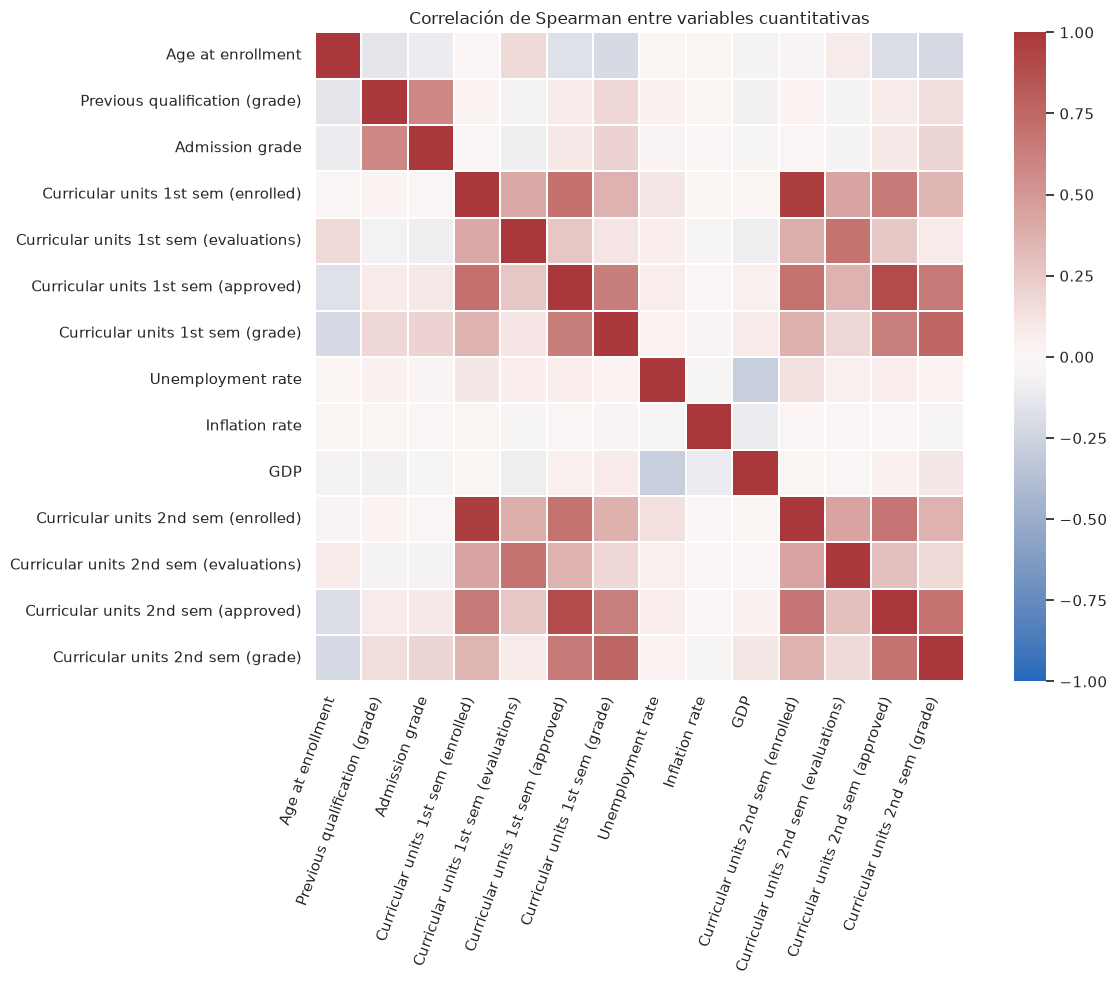

,Variable 1,Variable 2,rho de Spearman
1,Curricular units 1st sem (enrolled),Curricular units 2nd sem (enrolled),0.96
2,Curricular units 1st sem (approved),Curricular units 2nd sem (approved),0.89
3,Curricular units 1st sem (grade),Curricular units 2nd sem (grade),0.76
0,Curricular units 1st sem (enrolled),Curricular units 1st sem (approved),0.71


In [34]:
semester_measures = [
    f"Curricular units {semester} sem ({measure})"
    for semester in ["1st", "2nd"]
    for measure in ["enrolled", "evaluations", "approved", "grade"]
]
corr_cols = list(dict.fromkeys(quantitative_cols + [col for col in semester_measures if col in df.columns]))
spearman_corr = df[corr_cols].corr(method="spearman")

fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(
    spearman_corr, cmap="vlag", center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.3, ax=ax,
)
ax.set_title("Correlación de Spearman entre variables cuantitativas")
plt.xticks(rotation=70, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

strong_pairs = [
    (left, right, spearman_corr.loc[left, right])
    for i, left in enumerate(corr_cols)
    for right in corr_cols[i + 1:]
    if abs(spearman_corr.loc[left, right]) >= 0.70
]
strong_pairs_summary = pd.DataFrame(
    strong_pairs,
    columns=["Variable 1", "Variable 2", "rho de Spearman"],
).sort_values("rho de Spearman", key=lambda values: values.abs(), ascending=False)
display(strong_pairs_summary.round(2))

## 6. Segundo semestre y riesgo de *data leakage*

La decisión se plantea al cierre del primer semestre. Por tanto, las variables del segundo semestre no estarían disponibles para esa decisión y deben excluirse del escenario principal, aunque estén muy asociadas con el resultado final. La comparación siguiente es únicamente descriptiva y sirve para dimensionar ese riesgo.

En este dataset, la mediana de unidades aprobadas en el segundo semestre es 0 para `Dropout`, 4 para `Enrolled` y 6 para `Graduate`. Es una señal posterior al punto de predicción, no una característica válida para una alerta al cierre del primer semestre.

,Mediana aprobadas 1st semestre,Mediana nota 1st semestre,Mediana aprobadas 2nd semestre,Mediana nota 2nd semestre
Dropout,2.0,10.93,0.0,0.0
Enrolled,5.0,12.00,4.0,12.0
Graduate,6.0,13.00,6.0,13.0


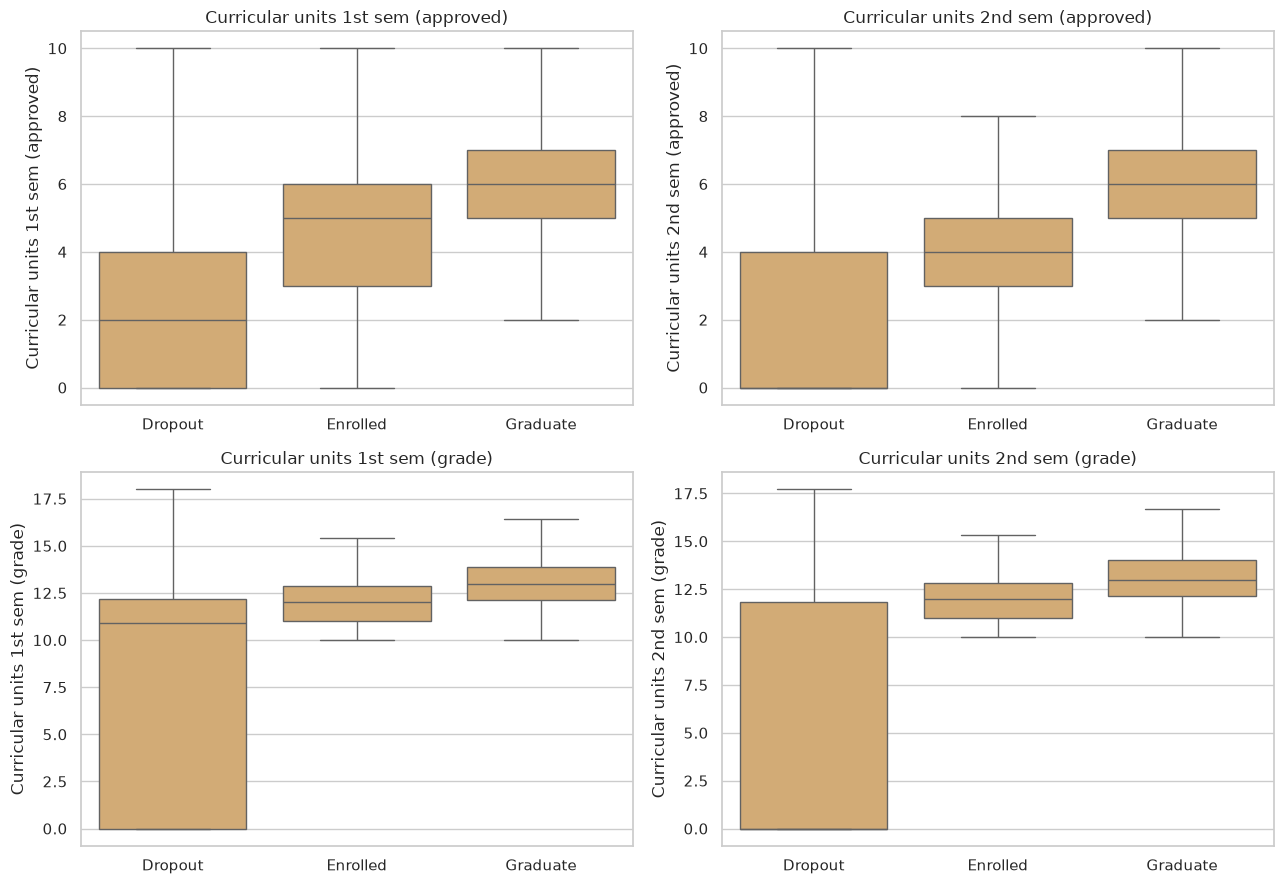

In [35]:
semester_outcomes = pd.DataFrame(index=["Dropout", "Enrolled", "Graduate"])
for semester in ["1st", "2nd"]:
    approved_col = f"Curricular units {semester} sem (approved)"
    grade_col = f"Curricular units {semester} sem (grade)"
    if approved_col in df.columns:
        semester_outcomes[f"Mediana aprobadas {semester} semestre"] = (
            df.groupby("Target")[approved_col].median().reindex(semester_outcomes.index)
        )
    if grade_col in df.columns:
        semester_outcomes[f"Mediana nota {semester} semestre"] = (
            df.groupby("Target")[grade_col].median().reindex(semester_outcomes.index)
        )
display(semester_outcomes.round(2))

leakage_cols = [
    "Curricular units 1st sem (approved)",
    "Curricular units 2nd sem (approved)",
    "Curricular units 1st sem (grade)",
    "Curricular units 2nd sem (grade)",
]
leakage_cols = [col for col in leakage_cols if col in df.columns]
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, col in zip(axes.flat, leakage_cols):
    sns.boxplot(data=df, x="Target", y=col, order=["Dropout", "Enrolled", "Graduate"], ax=ax, color="#e1ae67", showfliers=False)
    ax.set_title(col)
    ax.set_xlabel("")
plt.tight_layout()
plt.show()

## 7. Síntesis para preparación y modelamiento

### Hallazgos

- El CSV tiene 4.424 estudiantes, 36 predictores y tres clases; no presenta valores faltantes ni filas duplicadas exactas.
- La clase mayoritaria es `Graduate` (49,9%); `Dropout` representa 32,1%. Predecir siempre la clase mayoritaria no detecta desertores.
- La mediana de tasa de aprobación del primer semestre es 40% para `Dropout`, 80% para `Enrolled` y 100% para `Graduate`.
- Los segmentos con mayor tasa observada incluyen estudiantes con pagos no al día (86,6%; `n=528`) y la carrera Equinculture (55,3%; `n=141`, entre carreras con al menos 30 estudiantes). Estas cifras describen asociaciones del conjunto y no causas.
- Las diferencias por género y beca son marcadas; deben motivar evaluación de desempeño y equidad por segmentos, no reglas automáticas de tratamiento.

### Implicancias para el modelamiento

1. Mantener la formulación multiclase y comparar con `DummyClassifier` de clase mayoritaria.
2. Reportar F1 macro y recall de `Dropout`; dejar accuracy como métrica de referencia.
3. Utilizar únicamente variables disponibles en matrícula y al cierre del primer semestre para el escenario de alerta temprana.
4. Codificar explícitamente las categorías nominales. No tratar sus códigos enteros como magnitudes ni ordenar categorías por el número asignado.
5. Revisar las métricas por segmentos y presentar sus tamaños muestrales, especialmente cuando un grupo sea pequeño.
6. Interpretar importancias como asociaciones predictivas, no como efectos causales.
7. Considerar la procedencia portuguesa y la ambigüedad de `Enrolled` al discutir generalización a UPC/Perú.

### Hallazgos del análisis

- El CSV contiene 4.424 estudiantes, 36 predictores y tres clases; no presenta valores faltantes ni filas duplicadas exactas.
- `Graduate` es la clase mayoritaria (49,9%) y `Dropout` representa 32,1%. El baseline de clase mayoritaria obtiene 49,9% de accuracy, pero 0% de recall para desertores.
- La mediana de la tasa de aprobación del primer semestre es 40% para `Dropout`, 80% para `Enrolled` y 100% para `Graduate`. La tasa se deja indefinida para los 180 estudiantes sin cursos matriculados.
- Entre los segmentos revisados, la tasa de `Dropout` es 86,6% cuando los pagos no están al día (`n=528`). Por carrera, Equinculture presenta 55,3% (`n=141`) entre carreras con al menos 30 casos.
- La correlación de Spearman entre unidades matriculadas de ambos semestres es 0,96; entre unidades aprobadas es 0,89. Esto no altera la decisión temporal: segundo semestre queda excluido del escenario temprano.

### Decisiones para el modelamiento

1. Mantener la clasificación multiclase y comparar el modelo con `DummyClassifier` de clase mayoritaria.
2. Reportar F1 macro y recall de `Dropout`; usar accuracy como referencia.
3. Limitar predictores a información disponible al matricularse y al cierre del primer semestre.
4. Codificar categorías nominales explícitamente; sus números son etiquetas, no magnitudes.
5. Evaluar resultados por segmentos e incluir tamaños muestrales, con revisión de equidad para variables sensibles.
6. Interpretar asociaciones e importancias como predictivas, no causales.
7. Considerar la procedencia portuguesa y la ambigüedad de `Enrolled` al valorar la generalización a UPC/Perú.